<a href="https://colab.research.google.com/github/triukhan/computer-vision-lessons/blob/main/Homework_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOMEWORK 3

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
plt.rcParams['figure.figsize'] = [15, 10]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


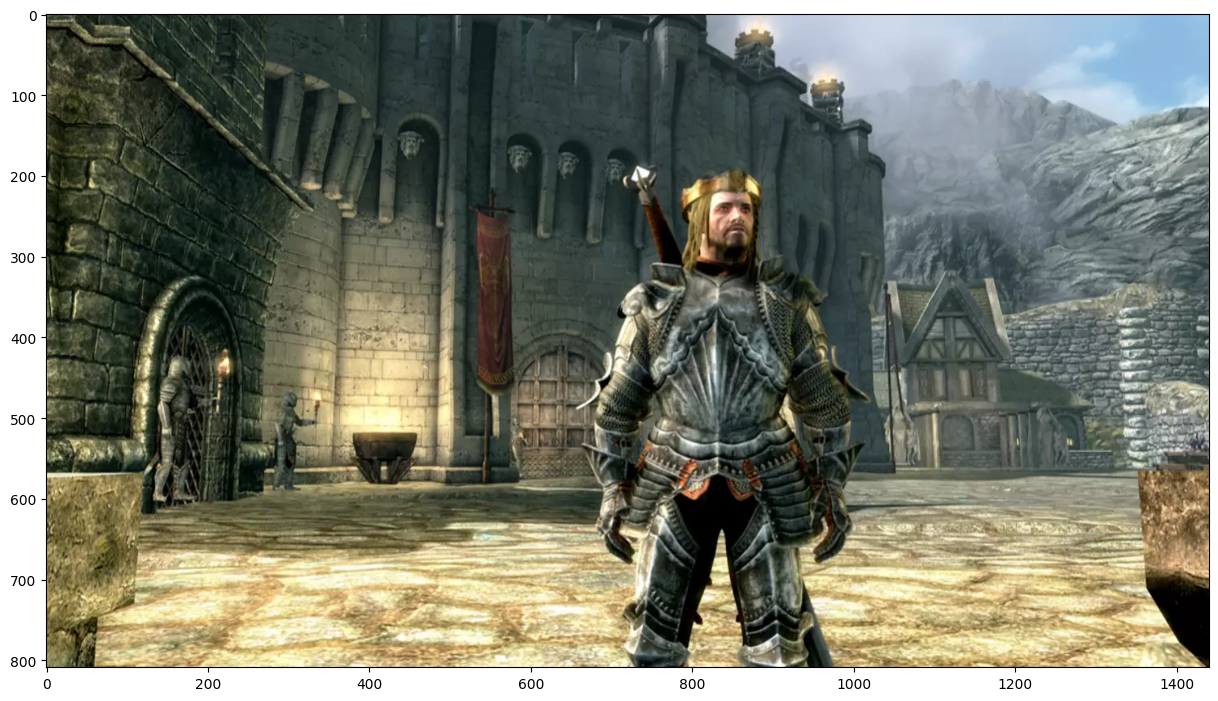

In [ ]:
img = cv2.imread('/content/drive/MyDrive/test.webp')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

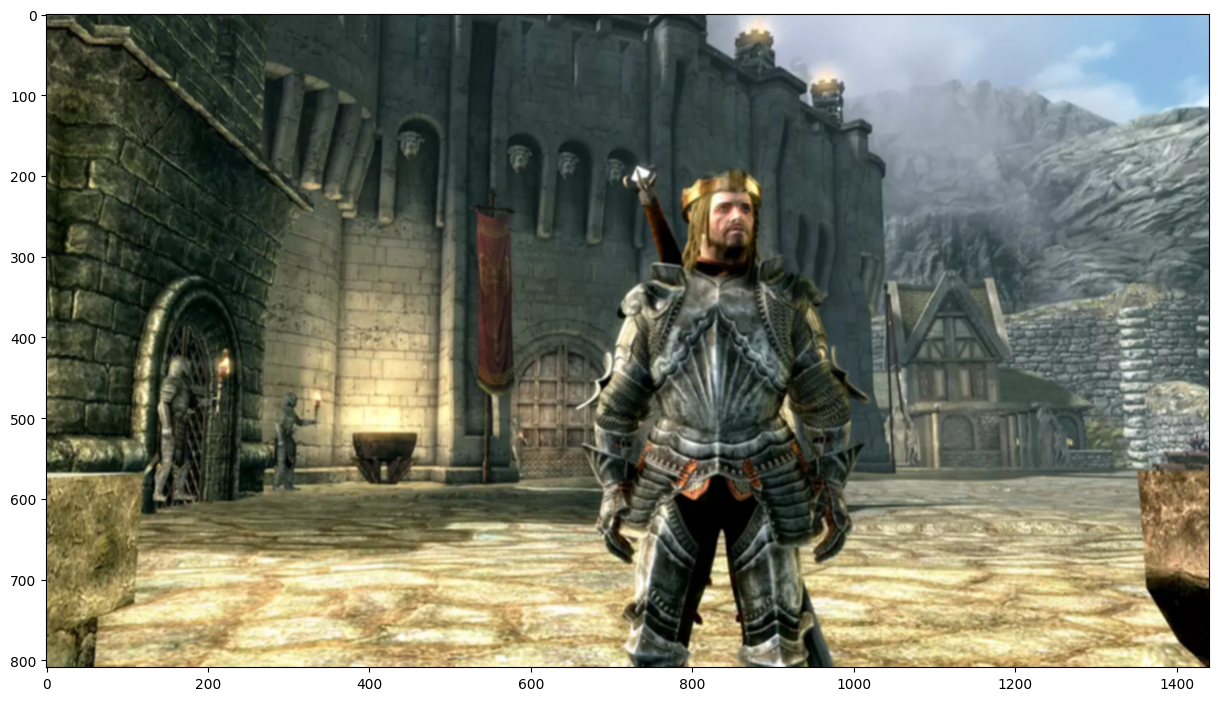

In [ ]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, [3, 3], 3)
plt.imshow(unsharp)

In [ ]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img.astype(np.float32) - unsharp.astype(np.float32)

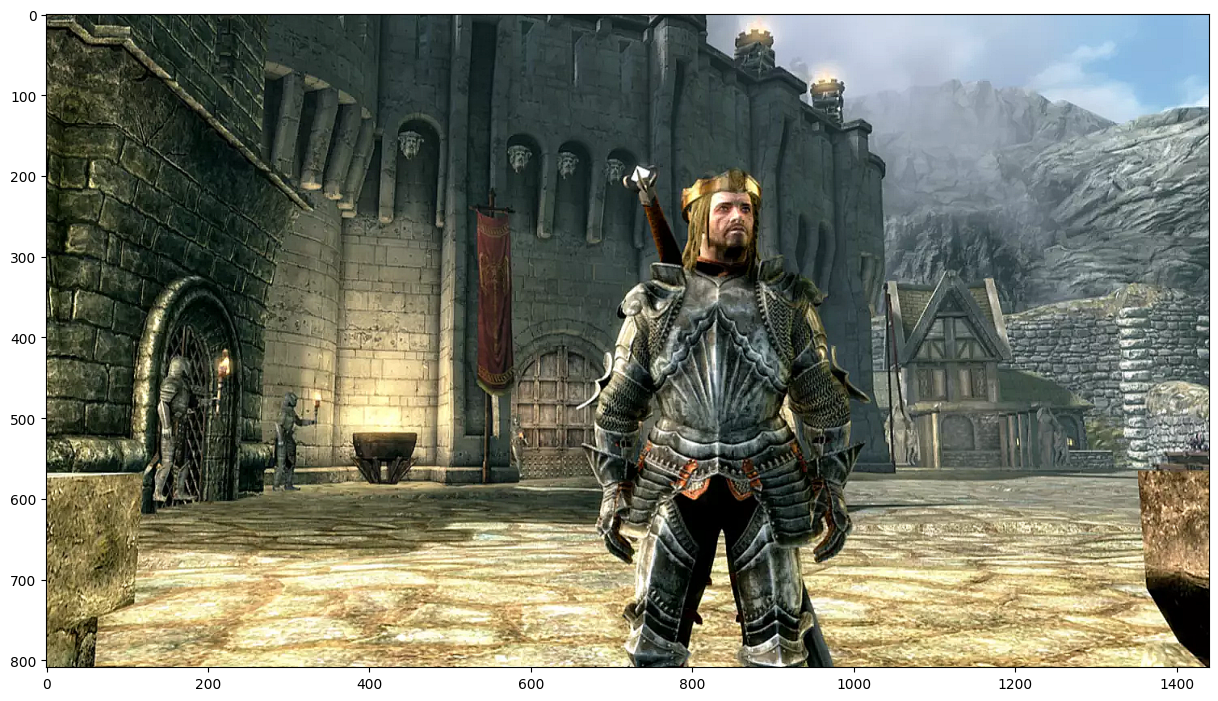

In [ ]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
sharpened = img.astype(np.float32) + diff * 2
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
plt.imshow(sharpened)

### Questions
* What is a good (reasonable) value for the `amount` parameter? - I guess it depends on image and GaussianBlur parameters, for example this image with different GaussianBlur parameteres and amount (but still <= 2) has no visible artefacts, and another picture with amount >= 1 has visible artefacts with GaussianBlur parameters ([3, 3] and sigma=3). So i guess reasonable parametres are from 0.5 to 2.
 * What happens if it is too small? - There is no noticable difference between original image and sharpened
 * What happens if it is too large? - There is too sharpened image so it's possible appear some artefacts